<a href="https://colab.research.google.com/github/reijohnson/DATA201-Labs/blob/main/week2_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Homework - ISL with Python

Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Question 8

In [8]:
college = pd.read_csv('https://www.statlearning.com/s/College.csv')
print(college[0:4])

                     Unnamed: 0 Private  Apps  Accept  Enroll  Top10perc  \
0  Abilene Christian University     Yes  1660    1232     721         23   
1            Adelphi University     Yes  2186    1924     512         16   
2                Adrian College     Yes  1428    1097     336         22   
3           Agnes Scott College     Yes   417     349     137         60   

   Top25perc  F.Undergrad  P.Undergrad  Outstate  Room.Board  Books  Personal  \
0         52         2885          537      7440        3300    450      2200   
1         29         2683         1227     12280        6450    750      1500   
2         50         1036           99     11250        3750    400      1165   
3         89          510           63     12960        5450    450       875   

   PhD  Terminal  S.F.Ratio  perc.alumni  Expend  Grad.Rate  
0   70        78       18.1           12    7041         60  
1   29        30       12.2           16   10527         56  
2   53        66       12.9

In [13]:
college2 = pd.read_csv('https://www.statlearning.com/s/College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')

college = college3
print(college[0:4])

                             Private  Apps  Accept  Enroll  Top10perc  \
College                                                                 
Abilene Christian University     Yes  1660    1232     721         23   
Adelphi University               Yes  2186    1924     512         16   
Adrian College                   Yes  1428    1097     336         22   
Agnes Scott College              Yes   417     349     137         60   

                              Top25perc  F.Undergrad  P.Undergrad  Outstate  \
College                                                                       
Abilene Christian University         52         2885          537      7440   
Adelphi University                   29         2683         1227     12280   
Adrian College                       50         1036           99     11250   
Agnes Scott College                  89          510           63     12960   

                              Room.Board  Books  Personal  PhD  Terminal  \
College   

In [14]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

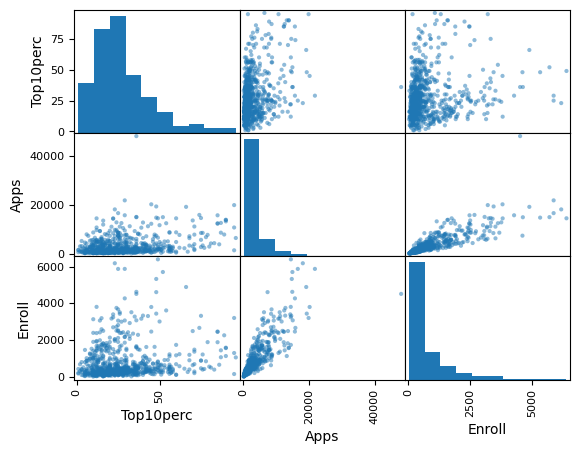

In [18]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']])

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

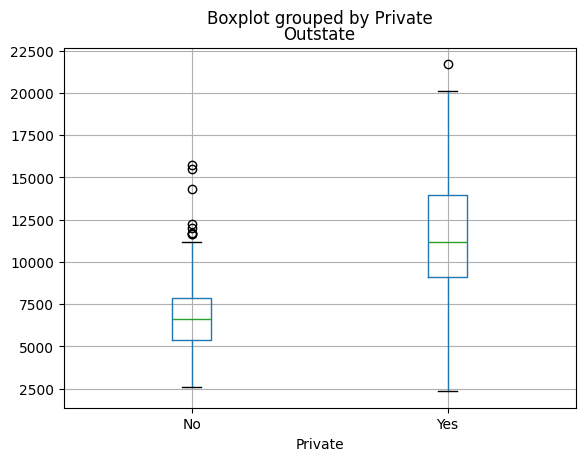

In [19]:
college.boxplot('Outstate', 'Private')

In [22]:
college['Elite'] = pd.cut(college['Top10perc'],
                          [0,0.5,1],
                          labels=['No', 'Yes'])

college['Elite'].value_counts()

,count
Elite,
Yes,3
No,0


<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

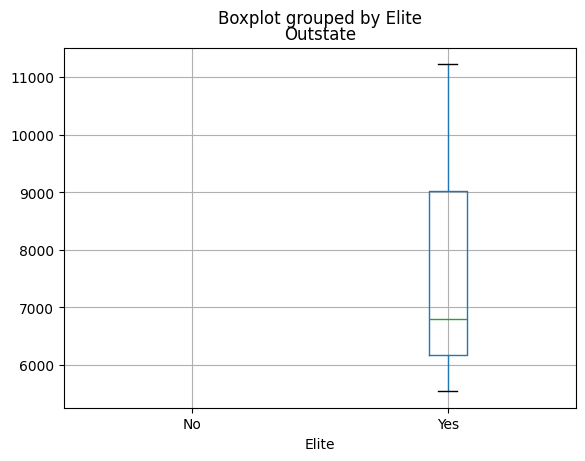

In [23]:
college.boxplot('Outstate', 'Elite')

<Axes: ylabel='Frequency'>

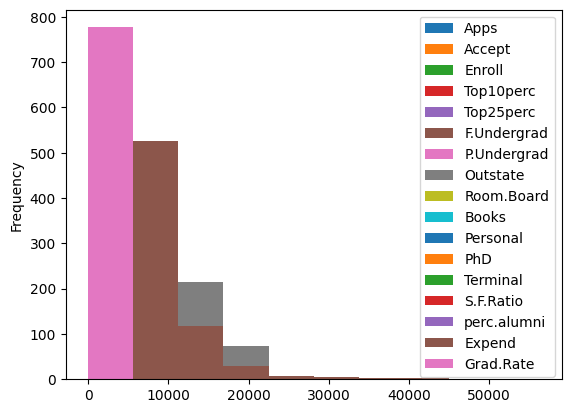

In [32]:
college.plot.hist()

15.448630655167198
100.0
103


Text(0, 0.5, 'Graduation Rate')

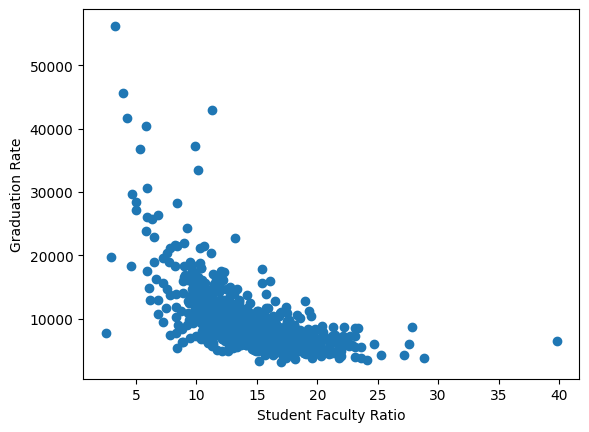

In [62]:
# Minimum Acceptance Rate
print(min(college['Accept']/college['Apps'])*100)

# Maximum Acceptance Rate
print(max(college['Accept']/college['Apps'])*100)

# Most PhDs at one school
print(max(college['PhD']))

# Expenditue versus Student Faculty Ratio
plt.scatter(college['S.F.Ratio'], college['Expend'])
plt.xlabel('Student Faculty Ratio')
plt.ylabel('Graduation Rate')

I learned from my exploration that there is a pattern between the expenditure and the student faculty ratio. As the expensiture increases the student to faculty ratio decreases, meaning there are less students per teacher.

I also saw that the minimum acceptance rate was 15.44% and the maximum number of PhDs from a single school was 103.

Question 9

In [82]:
auto = pd.read_csv('https://www.statlearning.com/s/Auto.csv', na_values=['?'])
auto = auto.set_index('name')
print(auto[0:4])

                            mpg  cylinders  displacement  horsepower  weight  \
name                                                                           
chevrolet chevelle malibu  18.0          8         307.0       130.0    3504   
buick skylark 320          15.0          8         350.0       165.0    3693   
plymouth satellite         18.0          8         318.0       150.0    3436   
amc rebel sst              16.0          8         304.0       150.0    3433   

                           acceleration  year  origin  
name                                                   
chevrolet chevelle malibu          12.0    70       1  
buick skylark 320                  11.5    70       1  
plymouth satellite                 11.0    70       1  
amc rebel sst                      12.0    70       1  


The origin and name are qualitative variables whereas the mpg, cylinders, displacement, horsepower, weight, acceleration, and year are all quantitative.

In [80]:
for col in auto:
  if col not in ['origin', 'name']:
    print(f"{col} Minimum            : {np.min(auto[col])}")
    print(f"{col} Maximum            : {np.max(auto[col])}")
    print(f"{col} Mean               : {np.mean(auto[col])}")
    print(f"{col} Standard Deviation : {np.std(auto[col])}")
    print(f"------------------------------------------")

mpg Minimum            : 9.0
mpg Maximum            : 46.6
mpg Mean               : 23.51586901763224
mpg Standard Deviation : 7.815941538224255
------------------------------------------
cylinders Minimum            : 3
cylinders Maximum            : 8
cylinders Mean               : 5.458438287153652
cylinders Standard Deviation : 1.699432585509141
------------------------------------------
displacement Minimum            : 68.0
displacement Maximum            : 455.0
displacement Mean               : 193.53274559193954
displacement Standard Deviation : 104.24803997948825
------------------------------------------
horsepower Minimum            : 46.0
horsepower Maximum            : 230.0
horsepower Mean               : 104.46938775510205
horsepower Standard Deviation : 38.442032714425984
------------------------------------------
weight Minimum            : 1613
weight Maximum            : 5140
weight Mean               : 2970.2619647355164
weight Standard Deviation : 846.835556847804

In [106]:
auto2 = pd.read_csv('https://www.statlearning.com/s/Auto.csv', na_values=['?'])
auto2 = pd.concat([auto2[0:10], auto2[86:]], axis=0)
print(auto2)

      mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0    18.0          8         307.0       130.0    3504          12.0    70   
1    15.0          8         350.0       165.0    3693          11.5    70   
2    18.0          8         318.0       150.0    3436          11.0    70   
3    16.0          8         304.0       150.0    3433          12.0    70   
4    17.0          8         302.0       140.0    3449          10.5    70   
..    ...        ...           ...         ...     ...           ...   ...   
392  27.0          4         140.0        86.0    2790          15.6    82   
393  44.0          4          97.0        52.0    2130          24.6    82   
394  32.0          4         135.0        84.0    2295          11.6    82   
395  28.0          4         120.0        79.0    2625          18.6    82   
396  31.0          4         119.0        82.0    2720          19.4    82   

     origin                       name  
0         1  chevrolet

In [107]:
for col in auto2:
  if col not in ['origin', 'name']:
    print(f"{col} Minimum            : {np.min(auto2[col])}")
    print(f"{col} Maximum            : {np.max(auto2[col])}")
    print(f"{col} Mean               : {np.mean(auto2[col])}")
    print(f"{col} Standard Deviation : {np.std(auto2[col])}")
    print(f"------------------------------------------")

mpg Minimum            : 11.0
mpg Maximum            : 46.6
mpg Mean               : 24.44485981308411
mpg Standard Deviation : 7.887612832492537
------------------------------------------
cylinders Minimum            : 3
cylinders Maximum            : 8
cylinders Mean               : 5.370716510903427
cylinders Standard Deviation : 1.650908119022154
------------------------------------------
displacement Minimum            : 68.0
displacement Maximum            : 455.0
displacement Mean               : 187.17445482866043
displacement Standard Deviation : 99.70889452054732
------------------------------------------
horsepower Minimum            : 46.0
horsepower Maximum            : 230.0
horsepower Mean               : 101.0031545741325
horsepower Standard Deviation : 35.9463759770665
------------------------------------------
weight Minimum            : 1649
weight Maximum            : 4997
weight Mean               : 2933.183800623053
weight Standard Deviation : 808.3765473031685
--

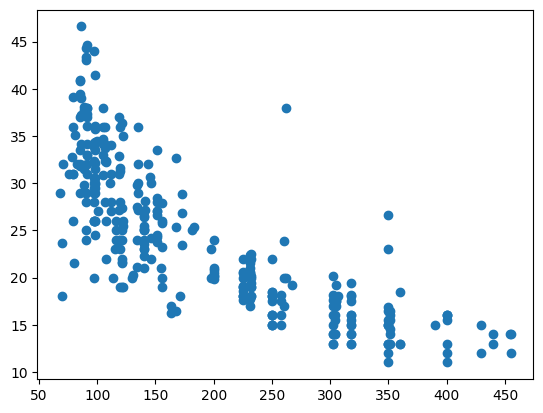

In [122]:
# Plot of Cylinders vs MPG
plt.scatter(auto2['displacement'], auto2['mpg'])

The graph above shows many things on it's own, the main being the relationship between displacement and miles per gallon.  With displacement on the X axis and mpg on the Y axis, you can see a negative correlation. As displacement rises, miles per gallon falls.

Another interesting takeaway from this graph is seeing how grouped the diplacement is. Toward the lower end, there are engines all over the chart, however for larger engines there are steps at around 240, 250, 260, 300, 310, 350, and 400.

Question 10

In [193]:
boston = pd.read_csv('/content/Boston.csv')
print(boston[0:4])

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   

   tax  ptratio  lstat  medv  
0  296     15.3   4.98  24.0  
1  242     17.8   9.14  21.6  
2  242     17.8   4.03  34.7  
3  222     18.7   2.94  33.4  


In [128]:
boston

# There are 506 rows in this edition of the Boston dataset
# There are 14 columns
# Each row is a boston suburb
# Each column is a statistic about that suburb

# https://intro-stat-learning.github.io/ISLP/datasets/Boston.html

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


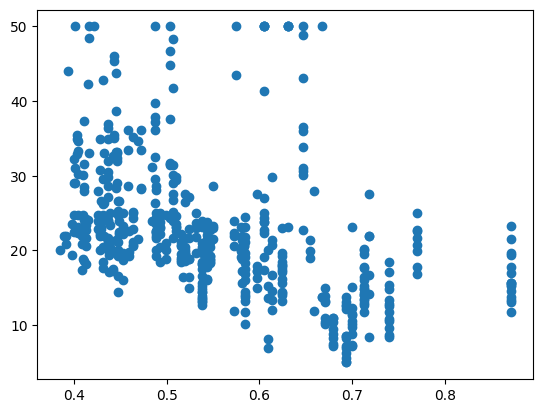

In [152]:
# Median Home value in $1000s versus Nitrogen Oxide Concentration in PP10M
plt.scatter(boston['nox'], boston['medv'])

Oddly enough, the places with more valuable homes (at or above ~$40,000) have Nitrogen Oxide concentration under 0.7ppm.

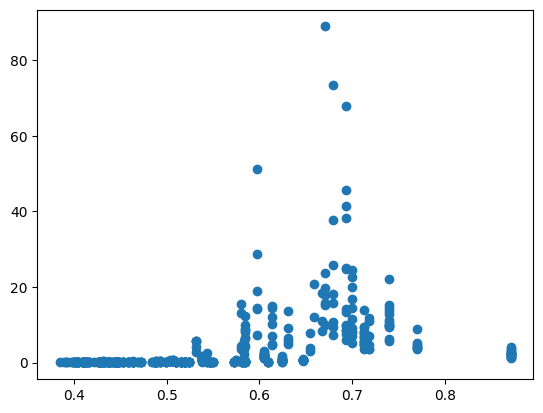

In [154]:
# Nitrogen Oxide Concentration in PP10M versus Crime Rate
plt.scatter(boston['nox'], boston['crim'])

This one is quite odd too: it appears that areas with higher nitrogen oxide concentrations have higher crime rates than those with lower nitrogen oxide concentrations.

The predictors I found to be associated with per capita crime rate were home value and nitrogen oxide concentration. The latter I go into above. I think the higher the home value is the more wealthy the area is and you see less crime compared to low income areas where crime may be needed to survive.

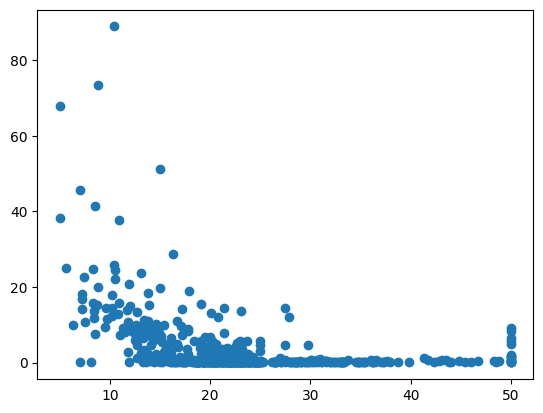

In [155]:
# Example of crime rate (y axis) and home value (x axis)
plt.scatter(boston['medv'], boston['crim'])

Looking at the CSV and sorting it by descending crime rate, tax rate, and ptratios we see:

High Crime Rates:
381, 419, 406

High Tax Rates:
491, 490, 489, 493, 492

High P-T Ratios: 356, 355 (Both Barely)

In [197]:
# Suburbs that bound the Charles River
boston.loc[lambda df: df['chas'] == True]

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
142,143,3.32105,0.0,19.58,1,0.8710,5.403,100.0,1.3216,5,403,14.7,26.82,13.4
152,153,1.12658,0.0,19.58,1,0.8710,5.012,88.0,1.6102,5,403,14.7,12.12,15.3
154,155,1.41385,0.0,19.58,1,0.8710,6.129,96.0,1.7494,5,403,14.7,15.12,17.0
155,156,3.53501,0.0,19.58,1,0.8710,6.152,82.6,1.7455,5,403,14.7,15.02,15.6
160,161,1.27346,0.0,19.58,1,0.6050,6.250,92.6,1.7984,5,403,14.7,5.50,27.0
162,163,1.83377,0.0,19.58,1,0.6050,7.802,98.2,2.0407,5,403,14.7,1.92,50.0
163,164,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403,14.7,3.32,50.0
208,209,0.13587,0.0,10.59,1,0.4890,6.064,59.1,4.2392,4,277,18.6,14.66,24.4
209,210,0.43571,0.0,10.59,1,0.4890,5.344,100.0,3.8750,4,277,18.6,23.09,20.0
210,211,0.17446,0.0,10.59,1,0.4890,5.960,92.1,3.8771,4,277,18.6,17.27,21.7


In [202]:
# Medial pupil-teacher ratio
# Note: I wrapped it in a float operator to avoid
# having the numpy.float64<> type declaration
float(np.median(boston['ptratio']))

19.05

In [204]:
# Suburb(s) with lowest median home value
minimumval = min(boston['medv'])
boston.loc[lambda df: df['medv'] == minimumval]

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
398,399,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0
405,406,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0


There are two values and looking at the others values, there is generally high crime, high nox level, and about 6 rooms per dwelling.

In [205]:
# Number of suburbs that average more than 8 rooms per dwelling
len(boston.loc[boston['rm'] > 7])

64

In [206]:
# Number of suburbs that average mor ethan 8 rooms per dwelling
len(boston.loc[boston['rm']>8])

13

There are very few homes in the boston area in general that have more than 8 rooms on average. This is likely reserved to the richer suburbs we found before if I had to venture a guess, but you would have to do more comparisons to do so.